<a href="https://colab.research.google.com/github/rgrandym/data_science_cambridge/blob/main/using_llm_for_topic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Using LLM from Hugging Face

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import torch
torch.random.manual_seed(0)
import psutil
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline, AutoModelForCausalLM
from tqdm import tqdm
import logging
from google.colab import userdata
import os
torch.random.manual_seed(0)

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Then access it in Colab:
file_path = "/content/drive/MyDrive/combined_reviews_goog_trustp_uk_clean.csv"  # Adjust path
combined_reviews_df = pd.read_csv(file_path)
print(combined_reviews_df.head())

                 location country   latitude  longitude      source  \
0  Aberdeen Kittybrewster      GB  57.161634   -2.11324      Google   
1  Aberdeen Kittybrewster      GB  57.161634   -2.11324  Trustpilot   
2  Aberdeen Kittybrewster      GB  57.161634   -2.11324  Trustpilot   
3  Aberdeen Kittybrewster      GB  57.161634   -2.11324  Trustpilot   
4  Aberdeen Kittybrewster      GB  57.161634   -2.11324  Trustpilot   

                                            comments          review_date  \
0  l left staff gym locker return l found locker ...  2024-05-05 08:24:21   
1  compared sites felt bit shabby. layout bit odd...  2024-04-18 08:45:00   
2                 overall pretty good, cant complain  2024-04-09 09:02:00   
3  many people gym, enough space time wait machin...  2024-04-04 22:59:00   
4                    resolved took hours longer good  2024-03-21 12:51:00   

   score  
0      1  
1      3  
2      4  
3      2  
4      4  


In [4]:
# Set random seed for reproducibility
np.random.seed(42)

# Create random subset of 50 rows with score <= 3
subset_size = 50

# First filter for reviews with score <= 3
low_score_reviews = combined_reviews_df[combined_reviews_df['score'] <= 3]

# Check if we have enough reviews
if len(low_score_reviews) < subset_size:
    print(f"Warning: Only {len(low_score_reviews)} reviews with score <= 3 available")
    subset_size = len(low_score_reviews)

# Create random subset
random_subset = low_score_reviews.sample(n=subset_size, random_state=42)

# Verify the subset
print(f"Created subset with {len(random_subset)} rows (all with score <= 3)")
print("Score distribution in subset:")
print(random_subset['score'].value_counts().sort_index())
print("\nSample of subset:")
print(random_subset.head())

# Save to CSV
random_subset.to_csv('random_low_score_subset_50.csv', index=False)

Created subset with 50 rows (all with score <= 3)
Score distribution in subset:
score
1    18
2    14
3    18
Name: count, dtype: int64

Sample of subset:
                  location country   latitude  longitude      source  \
5413                Harlow      GB  51.768557   0.094904  Trustpilot   
12238           New Barnet      GB  51.649745  -0.175140      Google   
1668         Bradford Idle      GB  53.835220  -1.730401  Trustpilot   
7838   London Canary Wharf      GB  51.504895  -0.019001      Google   
14081          Port Talbot      GB  51.595235  -3.782415      Google   

                                                comments          review_date  \
5413   gyms okay, lack free weights, showers smelt se...  2023-07-11 20:10:00   
12238  need better air conditioning. also, kind mad p...  2024-03-13 19:11:15   
1668              gym freezing cold showers boiling hot.  2023-10-15 22:32:00   
7838   made official complaint via email recommend wo...  2024-04-08 19:42:18   
14081  

In [5]:
# Create list of reviews from the negative reviews subset
random_subset_list = random_subset["comments"].to_list()
display(random_subset_list[:5])

['gyms okay, lack free weights, showers smelt sewage disgusting use. cannot find anywhere report it. could find staff. improve keeping better standard hygiene throughout gym reporting feature improvements',
 "need better air conditioning. also, kind mad pay £22 month & listen pop music + ads... think that's mad anyway",
 'gym freezing cold showers boiling hot.',
 'made official complaint via email recommend women same, see via reviews (and imagine haven’t said anything) fares mahhediene guy really issue women. love gym, equipment classes he’s really making hard come back. detailed everything via email gym would like also make “students” aware alone. picks people, see it’s vulnerable ones, maybe first class, asking help - shouldn’t really put vulnerable position gym safe space, right? everyone trying improve know struggles limits. guy unprofessional personal trainer i’ve ever met, he’s definitely wrong job role. needs therapy!',
 "could added 2nd floor. bit small maybe future refurbish 

In [3]:
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-4-mini-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-4-mini-instruct")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-4-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3.py: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

In [4]:
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

Device set to use cuda


In [5]:
generation_args = {
    "max_new_tokens": 500,
    "return_full_text": False,
    "do_sample": False,
}

In [14]:
topics_llm = []
print(len(random_subset_list))
for review in random_subset_list[0:50]:
    if len(str(review)) < 500:
        print("review -> ", review)
        messages_2 = [
            {"role": "system", "content": "You work as a data analyst for a top online gym company. Extract exactly 3 improvement topics from the review. Return ONLY a Python-style list of strings like [\"topic1\", \"topic2\", \"topic3\"]"},
            {"role": "user", "content": f"Extract 3 specific improvement topics from this review: {review}"},
        ]
        output = pipe(messages_2, **generation_args)

        try:
            # Clean the output string
            raw_output = output[0]['generated_text'].strip()
            # Remove any markdown formatting or line breaks
            clean_output = raw_output.replace('\n', '').replace('```', '')
            # Extract the first list found in the string
            start = clean_output.find('[')
            end = clean_output.find(']') + 1
            topic_list_string = clean_output[start:end]

            topic_list = json.loads(topic_list_string)
            topics_llm.append(topic_list)
        except (json.JSONDecodeError, ValueError, AttributeError) as e:
            print(f"Failed to parse output: {raw_output}")
            print(f"Error: {str(e)}")
            topics_llm.append([])  # Append empty list if parsing fails

# Save list as dataframe
df_topics = pd.DataFrame({
    'review': random_subset_list[0:len(topics_llm)],
    'topics': topics_llm
})
df_topics.to_csv('/content/drive/MyDrive/review_analysis_llm_final.csv', index=False)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


50
review ->  gyms okay, lack free weights, showers smelt sewage disgusting use. cannot find anywhere report it. could find staff. improve keeping better standard hygiene throughout gym reporting feature improvements


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


review ->  need better air conditioning. also, kind mad pay £22 month & listen pop music + ads... think that's mad anyway


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

review ->  unfortunately aircon gym, sweaty there, best avoided warmer months !


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


review ->  biggest issue layout . classes upstairs . seen alot people asked move sled push tracks middle sets make space class happen . hard train instructors classes going battling mics


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


review ->  great budget friendly gym, respectable range equipment accessories. couple qualms though, starters ‘return weights rack’ rule fully enforced thus gym floor untidy probable trip hazard. furthermore lack foldable ‘mini’ plastic benches great. it’s good gym.


In [15]:
print(topics_llm)
max_len = max(len(seq) for seq in topics_llm)
padded_topics_llm = [seq + [""] * (max_len - len(seq)) for seq in topics_llm]
print(padded_topics_llm)
np_topics_llm = np.array(padded_topics_llm)
np.save('np_topics_phi.npy', np_topics_llm)
loaded_arr = np.load('np_topics_phi.npy')
topics_llm = loaded_arr.tolist()
topic_string_array = [item for row in topics_llm for item in row if item.strip()]

[['free weights availability', 'hygiene and cleanliness', 'reporting feature for issues'], ['Air conditioning', 'Pricing', 'Music and advertisements'], ['Temperature control', 'Shower temperature', 'User comfort'], ['Space and Capacity', 'Accessibility and Facilities', 'Crowd Management and Peak Times'], ['Womens area equipment', 'Leg machines', 'Facility layout'], ['Class booking flexibility', 'Cancellation policy', 'Last-minute plan changes'], ['Customer service response time', 'Lifting equipment availability', 'Efficiency of gym operations'], ['cleanliness of changing rooms', 'maintenance of toilets', 'quality of exercising machines'], ['Workout sauna place', 'Air conditioning usage', 'Comfort during workouts'], ['Cleaning facilities', 'Blue roll cleaning spray', 'More cleaning stations'], ['Upgrade gym equipment', 'Increase gym space', 'Improve machine availability'], ['Age-appropriate content', 'Behavioral management', 'Space utilization'], ['Machine Maintenance', 'Wiring Issues',

In [6]:
# Then access it in Colab:
file_path = '/content/drive/MyDrive/review_analysis_llm_final.csv'
analyze_reviews_df = pd.read_csv(file_path)
print(analyze_reviews_df.head())

                                              review  \
0  gyms okay, lack free weights, showers smelt se...   
1  need better air conditioning. also, kind mad p...   
2             gym freezing cold showers boiling hot.   
3  made official complaint via email recommend wo...   
4  could added 2nd floor. bit small maybe future ...   

                                              topics  
0  ['free weights availability', 'hygiene and cle...  
1  ['Air conditioning', 'Pricing', 'Music and adv...  
2  ['Temperature control', 'Shower temperature', ...  
3  ['Space and Capacity', 'Accessibility and Faci...  
4  ['Womens area equipment', 'Leg machines', 'Fac...  


### BertTopic post LLM Analysis

In [8]:
!pip install bertopic umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [9]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import re


In [7]:
# Re-create list of topics
list_topics = analyze_reviews_df["topics"].to_list()
flat_list = [topic for item in list_topics for topic in eval(item)]
display(flat_list[:5])

['free weights availability',
 'hygiene and cleanliness',
 'reporting feature for issues',
 'Air conditioning',
 'Pricing']

In [ ]:
import nltk
nltk.download('punkt_tab')

In [33]:
# Preprocess comments for text generation using BertTopic from list of common reviews
def clean_gym_text(text: str) -> str:
    """Light cleaning for gym reviews before BERTopic.
    Retains context for BERT embeddings while removing noise."""
    # Basic cleanup
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\w+", "", text)  # Remove URLs/usernames
    text = re.sub(r"[^\w\s.,!?'-]", " ", text)       # Keep basic punctuation
    text = re.sub(r"\s+", " ", text).strip()          # Normalize whitespace

    # Optional: Remove domain-specific noise (only if critical)
    custom_stopwords = {"gym", "puregym", "staff"}  # Example
    words = nltk.word_tokenize(text)
    words = [word for word in words if word not in custom_stopwords]  # Light filtering

    return ' '.join(words)


# Apply the cleaning function to the combined reviews
cleaned_reviews_topics_llm = [clean_gym_text(review) for review in flat_list]
# Display the first few cleaned reviews
print("First 5 cleaned reviews:")
for review in cleaned_reviews_topics_llm[:5]:
    print(f"- {review}")

First 5 cleaned reviews:
- free weights availability
- hygiene and cleanliness
- reporting feature for issues
- air conditioning
- pricing


In [34]:
model_bert_llm = BERTopic(
    verbose=True,
    umap_model=UMAP(n_neighbors=5,
                  n_components=5,
                  min_dist=0.0,
                  random_state=42),
    hdbscan_model=HDBSCAN(min_cluster_size=10,
                         min_samples=3,
                         cluster_selection_epsilon=0.1,
                         prediction_data=True),
    min_topic_size=15,
    nr_topics=None,  # Disable auto-reduction
    top_n_words=10,  # Show more words per topic
    n_gram_range=(1, 2)  # Consider word pairs
)

# Fit the model
np.random.seed(42)
topics_bert_llm, probs_bert_llm = model_bert_llm.fit_transform(cleaned_reviews_topics_llm)

# Force topic reduction if needed
if len(set(topics_bert_llm)) < 5:
    model_bert_llm.reduce_topics(cleaned_reviews_topics_llm, nr_topics=10)

2025-07-02 15:36:06,890 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

2025-07-02 15:36:08,347 - BERTopic - Embedding - Completed ✓
2025-07-02 15:36:08,348 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-02 15:36:08,539 - BERTopic - Dimensionality - Completed ✓
2025-07-02 15:36:08,541 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-02 15:36:08,552 - BERTopic - Cluster - Completed ✓
2025-07-02 15:36:08,556 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-02 15:36:08,578 - BERTopic - Representation - Completed ✓


In [35]:
# Display the top five topics and their words
topics_bert_llm = model_bert_llm.get_topics()
for topic_id, words in list(topics_bert_llm.items())[:5]:
    print(f"Topic {topic_id}: {', '.join([word for word, _ in words])}")

Topic -1: air, air conditioning, conditioning, ventilation, workout, conditioning workout, conditioning system, comfort during, environment, conditioning ventilation
Topic 0: equipment, availability, maintenance, machine, equipment availability, equipment maintenance, weights, cardio, equipment equipment, functionality
Topic 1: management, and, class, space, facilities, behavior, class scheduling, layout, management class, space utilization
Topic 2: cleanliness, changing, and, maintenance, cleaning, and maintenance, cleanliness and, room, toilets, of
Topic 3: user, music, content, interface, interface design, volume, music volume, user interface, design, and advertisements


In [36]:
# Visualize the top topics as a bar chart with top 5 words for each topic
model_bert_llm.visualize_barchart(top_n_topics=8, n_words=5)

In [37]:
# Plot a heatmap, showcasing the similarity matrix
fig = model_bert_llm.visualize_heatmap(width=900, height=900)  # Adjust values as needed
fig.show()

### Pass thde output of the llm model as the input for the llm model, but pre-fix the following to the prompt: For the following text topics obtained from negative customer reviews, can you give some actionable insights that would help this gym company?
### Run the microsoft/Phi-4-mini-instruct model.List the output, ideally in the form of suggestions, that the company can employ to address customer concerns

In [8]:
# list_topics is the list of topics extracted from the first pass through the llm model.

topics_first_run_llm = []
print(f"Processing {len(list_topics)} reviews")

for i, topics in enumerate(list_topics[:50]):  # Added enumerate for better tracking
    try:
        if not topics:  # Skip empty entries
            continue

        print(f"Processing review {i+1} -> {topics}")
        messages_3 = [
            {"role": "system", "content": "You are a data analyst for a gym company. Compress these topics into actionable business insights. Return ONLY a numbered list with 1-5 items max."},
            {"role": "user", "content": f"Compress these topics into actionable insights: {topics}"}
        ]

        output = pipe(messages_3, **generation_args)
        raw_output = output[0]['generated_text'].strip()

        # Clean and store the raw output directly (since we want numbered list)
        clean_output = '\n'.join([line.strip() for line in raw_output.split('\n') if line.strip()])
        topics_first_run_llm.append(clean_output)

    except Exception as e:
        print(f"Error processing review {i+1}: {str(e)}")
        topics_first_run_llm.append("Processing Error")

# Save to dataframe
df_llm_insights = pd.DataFrame({
    'original_topics': list_topics[:len(topics_first_run_llm)],
    'compressed_insights': topics_first_run_llm
})
df_llm_insights.to_csv('/content/drive/MyDrive/review_analysis_llm_insights.csv', index=False)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processing 43 reviews
Processing review 1 -> ['free weights availability', 'hygiene and cleanliness', 'reporting feature for issues']


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processing review 2 -> ['Air conditioning', 'Pricing', 'Music and advertisements']


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

Processing review 41 -> ['Air conditioning', 'Ventilation', 'Climate control']


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processing review 42 -> ['Class layout and space utilization', 'Instructor training and mic management', 'Class scheduling and equipment placement']


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processing review 43 -> ['Return Weights Rack Policy', 'Gym Floor Cleanliness', 'Lack of Foldable Plastic Benches']


In [11]:
# Then access it in Colab:
file_path = '/content/drive/MyDrive/review_analysis_llm_insights.csv'
insights_df = pd.read_csv(file_path)
print(insights_df.head())

                                     original_topics  \
0  ['free weights availability', 'hygiene and cle...   
1  ['Air conditioning', 'Pricing', 'Music and adv...   
2  ['Temperature control', 'Shower temperature', ...   
3  ['Space and Capacity', 'Accessibility and Faci...   
4  ['Womens area equipment', 'Leg machines', 'Fac...   

                                 compressed_insights  
0  1. Increase free weights inventory to meet cus...  
1  1. Optimize air conditioning costs by implemen...  
2  1. Implement a smart temperature control syste...  
3  1. Optimize gym space utilization to maximize ...  
4  1. Invest in high-quality, diverse equipment f...  


# Using Gensin

In [5]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 req

In [5]:
# Import libraries
import re
import string
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim import corpora, models
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
import pandas as pd


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Perform the preprocessing required to run the LDA model from Gensim. Use the list of negative reviews (combined Google and Trustpilot reviews).



In [3]:
goog_trustp_rev_comb_uk_df = pd.read_csv('/content/drive/MyDrive/combined_reviews_goog_trustp_uk_clean.csv')
print(goog_trustp_rev_comb_uk_df.head())

                 location country   latitude  longitude      source  \
0  Aberdeen Kittybrewster      GB  57.161634   -2.11324      Google   
1  Aberdeen Kittybrewster      GB  57.161634   -2.11324  Trustpilot   
2  Aberdeen Kittybrewster      GB  57.161634   -2.11324  Trustpilot   
3  Aberdeen Kittybrewster      GB  57.161634   -2.11324  Trustpilot   
4  Aberdeen Kittybrewster      GB  57.161634   -2.11324  Trustpilot   

                                            comments          review_date  \
0  l left staff gym locker return l found locker ...  2024-05-05 08:24:21   
1  compared sites felt bit shabby. layout bit odd...  2024-04-18 08:45:00   
2                 overall pretty good, cant complain  2024-04-09 09:02:00   
3  many people gym, enough space time wait machin...  2024-04-04 22:59:00   
4                    resolved took hours longer good  2024-03-21 12:51:00   

   score  
0      1  
1      3  
2      4  
3      2  
4      4  


In [4]:
# Create list of negative reviews
negative_reviews_list = goog_trustp_rev_comb_uk_df[goog_trustp_rev_comb_uk_df['score'] <= 3]['comments'].to_list()
display(negative_reviews_list[:5])

["l left staff gym locker return l found locker broken padlock missing.spoke staff member l told threw away staff.who that.that disrespectful.you dont break someone's locker throw away staff.i felt disrespected",
 'compared sites felt bit shabby. layout bit odd real organisation. machines available weights limited cleaning stations paper towels.i felt atmosphere poor, background music playing low volume. gym staff particularly visible either.',
 'many people gym, enough space time wait machine want use.. plus boxing bag, even single jumping robe studio exercising!',
 'machines engaged kids phones left minutes',
 'busy crowded me. cancelling membership joining another gym.']

### Pre-process the text for Gensim analysis

In [6]:
# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Load spacy model (run: python -m spacy download en_core_web_sm)
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Please install spacy English model: python -m spacy download en_core_web_sm")


In [7]:
def preprocess_reviews_for_lda(reviews, min_len=3, max_len=15, deacc=True,
                              remove_numbers=True, custom_stopwords=None):

    # Initialize stopwords
    stop_words = set(stopwords.words('english'))
    stop_words.update(STOPWORDS)  # Add Gensim stopwords

    # Add common review-specific stopwords
    review_stopwords = {
        'gym', 'pure', 'puregym'
    }
    stop_words.update(review_stopwords)

    # Add custom stopwords if provided
    if custom_stopwords:
        stop_words.update(custom_stopwords)

    # Initialize lemmatizer
    lemmatizer = WordNetLemmatizer()

    def clean_text(text):
        """Clean individual text"""
        if pd.isna(text) or text == '':
            return ''

        # Convert to lowercase
        text = text.lower()

        # Remove URLs and email addresses
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'\S+@\S+', '', text)

        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)

        # Remove extra whitespace and newlines
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()

        return text

    def tokenize_and_process(text):
        """Tokenize and process text"""
        # Use Gensim's simple_preprocess for initial tokenization
        tokens = simple_preprocess(text, deacc=deacc, min_len=min_len, max_len=max_len)

        # Remove numbers if specified
        if remove_numbers:
            tokens = [token for token in tokens if not token.isdigit()]

        # Remove stopwords
        tokens = [token for token in tokens if token not in stop_words]

        # Remove tokens that are just punctuation
        tokens = [token for token in tokens if not all(c in string.punctuation for c in token)]

        # Lemmatize tokens
        tokens = [lemmatizer.lemmatize(token) for token in tokens]

        # Remove very short tokens after lemmatization
        tokens = [token for token in tokens if len(token) >= min_len]

        return tokens

    def spacy_process(text):
        """Alternative processing with spaCy (more accurate but slower)"""
        doc = nlp(text)

        tokens = []
        for token in doc:
            # Skip if stopword, punctuation, space, or number (if specified)
            if (token.is_stop or token.is_punct or token.is_space or
                (remove_numbers and token.like_num) or
                len(token.text) < min_len or len(token.text) > max_len):
                continue

            # Use lemma, convert to lowercase
            lemma = token.lemma_.lower()

            # Additional cleaning
            if lemma not in stop_words and lemma.isalpha():
                tokens.append(lemma)

        return tokens

    # Process all reviews
    processed_docs = []

    print(f"Processing {len(reviews)} reviews...")

    for i, review in enumerate(reviews):
        if i % 1000 == 0:
            print(f"Processed {i} reviews...")

        # Clean text
        cleaned_text = clean_text(str(review))

        if len(cleaned_text) == 0:
            continue

        # Process tokens (choose one method)
        # Method 1: Simple preprocessing (faster)
        processed_tokens = tokenize_and_process(cleaned_text)

        # Method 2: SpaCy preprocessing (more accurate, uncomment to use)
        # processed_tokens = spacy_process(cleaned_text)

        # Only keep documents with sufficient tokens
        if len(processed_tokens) >= 3:  # Minimum 3 tokens per document
            processed_docs.append(processed_tokens)

    print(f"Preprocessing complete. {len(processed_docs)} documents ready for LDA.")

    return processed_docs


# Call preprocess_reviews_for_lda
processed_docs = preprocess_reviews_for_lda(
    negative_reviews_list,
    min_len=3,
    max_len=15,
    custom_stopwords={'gym', 'pure', 'puregym'}  # Add domain-specific stopwords
)


Processing 5458 reviews...
Processed 0 reviews...
Processed 1000 reviews...
Processed 2000 reviews...
Processed 3000 reviews...
Processed 4000 reviews...
Processed 5000 reviews...
Preprocessing complete. 5142 documents ready for LDA.


In [8]:
# Create corpus with processed reviews
def create_lda_corpus(processed_docs, no_below=5, no_above=0.7, keep_n=10000):
    # Create dictionary
    dictionary = corpora.Dictionary(processed_docs)

    print(f"Dictionary created with {len(dictionary)} unique tokens")

    # Filter extremes
    dictionary.filter_extremes(no_below=no_below, no_above=no_above, keep_n=keep_n)

    print(f"After filtering: {len(dictionary)} unique tokens")

    # Create corpus
    corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

    print(f"Corpus created with {len(corpus)} documents")

    return dictionary, corpus

# Call create_lda_corpus

dictionary, corpus = create_lda_corpus(
        processed_docs,
        no_below=2,      # Must appear in at least 2 documents
        no_above=0.8,    # Must appear in less than 80% of documents
        keep_n=5000      # Keep top 5000 most frequent words
    )

# Now ready for LDA modeling
print("Ready for LDA modeling!")
print(f"Sample processed document: {processed_docs[0]}")


Dictionary created with 9256 unique tokens
After filtering: 5000 unique tokens
Corpus created with 5142 documents
Ready for LDA modeling!
Sample processed document: ['left', 'staff', 'locker', 'return', 'locker', 'broken', 'padlock', 'missing', 'spoke', 'staff', 'member', 'told', 'threw', 'away', 'staff', 'disrespectful', 'dont', 'break', 'locker', 'throw', 'away', 'staff', 'felt', 'disrespected']


### # Using Gensim, perform LDA on the tokenised data. Specify the number of topics = 10.Show the visualisations of the topics, displaying the distance maps and the bar chart listing out the most salient terms.Comment on the output and whether it is similar to other techniques, and whether any extra insights were obtained.

In [10]:
#!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.1 MB/s eta 0:00:00


In [11]:
from gensim.models.ldamodel import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [12]:
# Create the LDA model
def train_lda_model(corpus, dictionary, num_topics=10, passes=20, random_state=42):
    """
    Train LDA model with specified parameters

    Args:
        corpus: Gensim corpus (bag of words)
        dictionary: Gensim dictionary
        num_topics: Number of topics to extract
        passes: Number of passes through the corpus during training
        random_state: Random seed for reproducibility

    Returns:
        lda_model: Trained LDA model
    """
    print(f"Training LDA model with {num_topics} topics...")

    lda_model = LdaModel(
        corpus=corpus,
        num_topics=num_topics,
        id2word=dictionary,
        passes=passes,
        random_state=random_state,
        alpha='auto',           # Document-topic density
        eta='auto',             # Topic-word density
        per_word_topics=True    # Compute word-topic probabilities
    )

    print("LDA model training completed!")
    return lda_model

# Call train_lda_model
lda_model = train_lda_model(corpus, dictionary, num_topics=10, passes=20)

Training LDA model with 10 topics...
LDA model training completed!


In [13]:
# Display topics
def display_topics(lda_model, num_words=10):
    """
    Display the topics found by LDA model

    Args:
        lda_model: Trained LDA model
        num_words: Number of words to display per topic
    """
    print("Topics found by LDA:")
    print("=" * 50)

    topics = lda_model.print_topics(num_words=num_words)

    for topic_id, topic_words in topics:
        print(f"Topic {topic_id}:")
        print(f"  {topic_words}")
        print()
# Call display_topics
display_topics(lda_model, num_words=10)

Topics found by LDA:
Topic 0:
  0.033*"room" + 0.033*"toilet" + 0.028*"changing" + 0.023*"dirty" + 0.022*"smell" + 0.021*"broken" + 0.019*"machine" + 0.014*"equipment" + 0.014*"clean" + 0.012*"locker"

Topic 1:
  0.027*"air" + 0.023*"equipment" + 0.018*"cleaning" + 0.013*"like" + 0.013*"station" + 0.013*"good" + 0.012*"need" + 0.012*"machine" + 0.012*"use" + 0.010*"hot"

Topic 2:
  0.024*"day" + 0.024*"membership" + 0.017*"time" + 0.016*"parking" + 0.012*"month" + 0.011*"email" + 0.011*"pay" + 0.011*"help" + 0.011*"staff" + 0.011*"hour"

Topic 3:
  0.034*"weight" + 0.032*"people" + 0.013*"phone" + 0.012*"place" + 0.011*"staff" + 0.011*"rack" + 0.011*"machine" + 0.011*"bench" + 0.010*"area" + 0.009*"time"

Topic 4:
  0.034*"staff" + 0.033*"member" + 0.019*"manager" + 0.015*"rude" + 0.011*"issue" + 0.011*"review" + 0.010*"customer" + 0.010*"experience" + 0.010*"said" + 0.009*"personal"

Topic 5:
  0.053*"equipment" + 0.049*"machine" + 0.026*"time" + 0.019*"good" + 0.018*"busy" + 0.013*"u

In [14]:
# Get topic probabilities for documents
def get_document_topics(lda_model, corpus):
    """
    Get topic probabilities for each document

    Args:
        lda_model: Trained LDA model
        corpus: Original corpus

    Returns:
        doc_topics: List of topic probabilities for each document
    """
    doc_topics = []

    for doc in corpus:
        topic_probs = lda_model.get_document_topics(doc)
        doc_topics.append(topic_probs)

    return doc_topics

# Call get_document_topics
doc_topics = get_document_topics(lda_model, corpus)

In [15]:
# Convert topic probabilities to DataFrame
def topics_to_dataframe(doc_topics, num_topics):
    """
    Convert document topic probabilities to DataFrame

    Args:
        doc_topics: Output from get_document_topics()
        num_topics: Number of topics in the model

    Returns:
        df_topics: DataFrame with topic probabilities
    """
    # Initialize matrix with zeros
    topic_matrix = np.zeros((len(doc_topics), num_topics))

    # Fill in the probabilities
    for doc_idx, topics in enumerate(doc_topics):
        for topic_id, prob in topics:
            topic_matrix[doc_idx, topic_id] = prob

    # Create DataFrame
    column_names = [f'Topic_{i}' for i in range(num_topics)]
    df_topics = pd.DataFrame(topic_matrix, columns=column_names)

    return df_topics

# Call topics_to_dataframe
df_topics = topics_to_dataframe(doc_topics, num_topics=10)
print("Topic probabilities DataFrame shape:", df_topics.shape)

Topic probabilities DataFrame shape: (5142, 10)


In [16]:
# Get dominant topic for each document
def get_dominant_topics(doc_topics):
    """
    Get the dominant topic for each document

    Args:
        doc_topics: Output from get_document_topics()

    Returns:
        dominant_topics: List of dominant topic IDs
        dominant_probs: List of dominant topic probabilities
    """
    dominant_topics = []
    dominant_probs = []

    for topics in doc_topics:
        if topics:  # Check if not empty
            # Get topic with highest probability
            dominant_topic, dominant_prob = max(topics, key=lambda x: x[1])
            dominant_topics.append(dominant_topic)
            dominant_probs.append(dominant_prob)
        else:
            dominant_topics.append(-1)  # No dominant topic
            dominant_probs.append(0.0)

    return dominant_topics, dominant_probs

# Call get_dominant_topics
dominant_topics, dominant_probs = get_dominant_topics(doc_topics)

In [17]:
# Visualize topics with pyLDAvis
def visualize_topics(lda_model, corpus, dictionary):
    """
    Create interactive topic visualization

    Args:
        lda_model: Trained LDA model
        corpus: Original corpus
        dictionary: Gensim dictionary

    Returns:
        vis: pyLDAvis visualization object
    """
    print("Creating topic visualization...")

    vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)

    return vis

# Call visualize_topics
vis = visualize_topics(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

Creating topic visualization...


In [21]:
def create_topic_labels(lda_model, num_words=3):
    """
    Create topic labels using top words from each topic

    Args:
        lda_model: Trained LDA model
        num_words: Number of top words to use for label

    Returns:
        topic_labels: List of topic labels
    """
    topic_labels = []

    for topic_id in range(lda_model.num_topics):
        # Get top words for this topic
        words = lda_model.show_topic(topic_id, topn=num_words)
        # Create label from top words
        label = ', '.join([word for word, prob in words])
        topic_labels.append(label)

    return topic_labels

# Call create_topic_labels
topic_labels = create_topic_labels(lda_model, num_words=3)

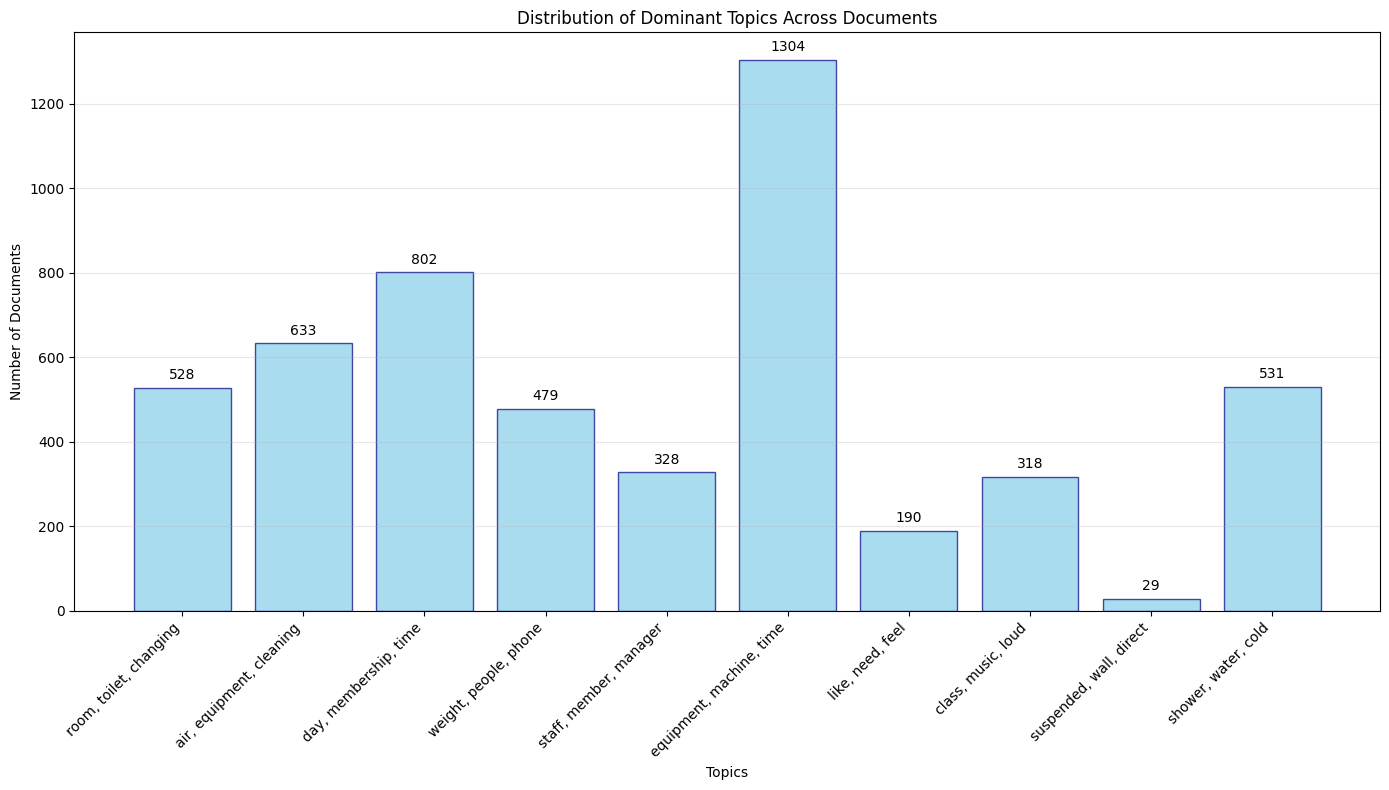

In [23]:
# Plot topic distribution
def plot_topic_distribution(dominant_topics, num_topics, topic_labels=None, figsize=(14, 8)):
    """
    Plot distribution of dominant topics across documents

    Args:
        dominant_topics: List of dominant topic IDs
        num_topics: Number of topics in model
        topic_labels: List of topic names/labels (optional)
        figsize: Figure size tuple
    """
    # Count topics
    topic_counts = np.bincount(dominant_topics, minlength=num_topics)

    # Create topic labels if not provided
    if topic_labels is None:
        topic_labels = [f'Topic {i}' for i in range(num_topics)]

    # Create plot
    plt.figure(figsize=figsize)
    bars = plt.bar(range(num_topics), topic_counts, color='skyblue', edgecolor='navy', alpha=0.7)
    plt.xlabel('Topics')
    plt.ylabel('Number of Documents')
    plt.title('Distribution of Dominant Topics Across Documents')

    # Set x-axis labels
    plt.xticks(range(num_topics), topic_labels, rotation=45, ha='right')

    # Add value labels on bars
    for i, count in enumerate(topic_counts):
        plt.text(i, count + max(topic_counts) * 0.01, str(count),
                ha='center', va='bottom')

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot with topic labels
plot_topic_distribution(dominant_topics, num_topics=10, topic_labels=topic_labels)


In [25]:
def get_topic_keywords(lda_model, num_words=10):
    """
    Extract keywords for each topic

    Args:
        lda_model: Trained LDA model
        num_words: Number of keywords per topic

    Returns:
        topic_keywords: Dictionary mapping topic_id to list of keywords
    """
    topic_keywords = {}

    for topic_id in range(lda_model.num_topics):
        # Get top words for this topic
        words = lda_model.show_topic(topic_id, topn=num_words)
        # Extract just the words (not probabilities)
        keywords = [word for word, prob in words]
        topic_keywords[topic_id] = keywords

    return topic_keywords

# Call get_topic_keywords
topic_keywords = get_topic_keywords(lda_model, num_words=10)

In [31]:
topic_keywords_df = pd.DataFrame(topic_keywords).T
topic_keywords_df.columns = [f'Keyword_{i+1}' for i in range(10)]
topic_keywords_df.index.name = 'Topic'
topic_keywords_df.head()

,Keyword_1,Keyword_2,Keyword_3,Keyword_4,Keyword_5,Keyword_6,Keyword_7,Keyword_8,Keyword_9,Keyword_10
Topic,,,,,,,,,,
0,room,toilet,changing,dirty,smell,broken,machine,equipment,clean,locker
1,air,equipment,cleaning,like,station,good,need,machine,use,hot
2,day,membership,time,parking,month,email,pay,help,staff,hour
3,weight,people,phone,place,staff,rack,machine,bench,area,time
4,staff,member,manager,rude,issue,review,customer,experience,said,personal


In [26]:
# Calculate topic coherence
def calculate_coherence(lda_model, processed_docs, dictionary):
    """
    Calculate coherence score for the LDA model

    Args:
        lda_model: Trained LDA model
        processed_docs: Preprocessed documents (list of token lists)
        dictionary: Gensim dictionary

    Returns:
        coherence_score: Coherence value
    """
    from gensim.models import CoherenceModel

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=processed_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_score = coherence_model.get_coherence()
    return coherence_score

# Call calculate_coherence
coherence_score = calculate_coherence(lda_model, processed_docs, dictionary)
print(f"Coherence Score: {coherence_score}")

Coherence Score: 0.5104110292788471


A Coherence Score of 0.5104 indicates moderate topic quality for the LDA model. Coherence evaluates how semantically similar the top words in each topic are to each other.

- Coherence scores typically range from 0 to 1 (sometimes higher)

0.3-0.5: Low to moderate coherence
0.5-0.7: Good coherence
0.7+: Excellent coherence

My Score 0f 0.51 indicates that topics are somewhat coherent but could be improved. The result is not bad, but there's room for optimization, since it is just above the "acceptable" threshold.

Topic Modeling Comparison: LDA, BERT, and LLM Approaches
- The topics extracted using the LDA model show good similarity to those obtained through BERT-based embeddings and large language model (LLM) approaches. However, each method offers distinct advantages depending on the specific use case and available resources.

- LDA remains valuable for its interpretability, computational efficiency, and established theoretical foundation. It provides transparent probabilistic topic assignments and requires minimal computational resources, making it accessible for organizations with limited infrastructure. The model's simplicity also facilitates easy parameter tuning and result interpretation.

- BERT-based approaches (such as BERTopic or sentence-BERT clustering) leverage contextual embeddings to capture semantic relationships more effectively than traditional bag-of-words models like LDA. These methods often produce more coherent topics by understanding word context and can handle polysemy better. BERT models strike a good balance between performance and computational requirements, especially when using pre-trained models.

- Large Language Models (LLMs) demonstrate superior performance in generating actionable insights and providing nuanced topic interpretations. They excel at understanding context, handling complex semantic relationships, and generating human-like topic descriptions. However, LLMs require substantial computational resources, have higher latency, and may present challenges in terms of reproducibility and cost, particularly for large-scale applications.

- Practical Recommendations:

LDA: Ideal for exploratory analysis, when interpretability is crucial, or with limited computational resources
BERT-based methods: Optimal balance of performance and efficiency for most production applications
LLMs: Best suited for high-stakes applications requiring nuanced understanding and when computational resources are abundant

The choice between these approaches should consider factors such as dataset size, required interpretability, available computational resources, latency requirements, and the need for real-time processing. A hybrid approach, using LDA or BERT for initial topic discovery followed by LLM-based refinement and interpretation, often provides the most comprehensive solution.